## 🧱 1. Armado del Dataset

Se parte del dataset original de ventas sell-in.

Granularidad: `<product_id, periodo>`

Transformación:
- Agrupar por `product_id`, `periodo`
- Sumarizar `tn` (toneladas)


In [1]:
import pandas as pd

# Cargar el archivo de sell-in (ajustar el path si es necesario)
df_raw = pd.read_csv("../data/original_source/sell-in.txt", sep="\t", encoding="utf-8")

# Agrupar por product_id y periodo
df_agg = (
    df_raw.groupby(['product_id', 'periodo'], as_index=False)
           .agg({'tn': 'sum'})
           .sort_values(['product_id', 'periodo'])
)

df_agg.head()


FileNotFoundError: [Errno 2] No such file or directory: '../data/original_source/sell-in.txt'

In [ ]:
df_agg.shape

(31243, 3)

## 🧮 2. Cálculo de la Clase (target)

Se crea un nuevo campo `clase` que representa `tn` en `periodo + 2`.

Notas:
- Para calcularlo se hace un merge desplazando dos períodos hacia atrás por `product_id`.
- Los períodos `201911` y `201912` quedan sin target (NaN).


In [ ]:
# Asegurarse de que periodo sea tipo entero
df_agg['periodo'] = df_agg['periodo'].astype(int)

# Crear índice temporal: mes_abs (mes absoluto)
periodos_ordenados = sorted(df_agg['periodo'].unique())
map_periodo_to_mesabs = {p: i + 1 for i, p in enumerate(periodos_ordenados)}

# Agregar columna mes_abs
df_agg['mes_abs'] = df_agg['periodo'].map(map_periodo_to_mesabs)

# Ordenar correctamente por producto y tiempo
df_agg = df_agg.sort_values(['product_id', 'mes_abs'])

# Crear campo tn+2 (la clase) como tn desplazado -2 hacia adelante
df_agg['tn+2'] = df_agg.groupby('product_id')['tn'].shift(-2)

# Revisar el resultado
df_agg.head(40)


,product_id,periodo,tn,mes_abs,tn+2
0,20001,201701,934.77222,1,1303.35771
1,20001,201702,798.01620,2,1069.96130
2,20001,201703,1303.35771,3,1502.20132
3,20001,201704,1069.96130,4,1520.06539
4,20001,201705,1502.20132,5,1030.67391
5,20001,201706,1520.06539,6,1267.39462
6,20001,201707,1030.67391,7,1316.94604
7,20001,201708,1267.39462,8,1439.75563
8,20001,201709,1316.94604,9,1580.47401
9,20001,201710,1439.75563,10,1049.38860


## 🛠️ 3. Feature Engineering: Lags

Se generan 11 columnas de `tn` anteriores (tn_1 a tn_11), por `product_id`.

En cada fila, se tiene el historial de 12 meses completos si está disponible:
- `tn`, `tn_1`, ..., `tn_11`

No se generan features adicionales.


In [ ]:
# Crear los lags tn_1 a tn_11
for lag in range(1, 12):
    df_agg[f'tn_{lag}'] = df_agg.groupby('product_id')['tn'].shift(lag)

df_agg.head()


,product_id,periodo,tn,mes_abs,tn+2,tn_1,tn_2,tn_3,tn_4,tn_5,tn_6,tn_7,tn_8,tn_9,tn_10,tn_11
0,20001,201701,934.77222,1,1303.35771,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20001,201702,798.01620,2,1069.96130,934.77222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20001,201703,1303.35771,3,1502.20132,798.01620,934.77222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20001,201704,1069.96130,4,1520.06539,1303.35771,798.01620,934.77222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20001,201705,1502.20132,5,1030.67391,1069.96130,1303.35771,798.01620,934.77222,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Agarramos la info de los productos
df_prod = pd.read_csv("../data/original_source/tb_productos.txt", sep="\t")
df_prod.shape
df_prod.head()

,cat1,cat2,cat3,brand,sku_size,product_id,descripcion
0,FOODS,ADEREZOS,Aji Picante,NATURA,240,20609,Salsa Aji Picante
1,FOODS,ADEREZOS,Barbacoa,NATURA,250,20266,Salsa Barbacoa
2,FOODS,ADEREZOS,Barbacoa,NATURA,400,20325,Salsa Barbacoa
3,FOODS,ADEREZOS,Barbacoa,NATURA,500,20503,Salsa Barbacoa
4,FOODS,ADEREZOS,Chimichurri,NATURA,350,20797,Chimichurri


In [ ]:
# df_prod.to_csv("df_prod.csv", index=False)

In [ ]:
df_agg_prod = pd.merge(df_agg, df_prod, on='product_id', how='left')
df_agg_prod.head()

,product_id,periodo,tn,mes_abs,tn+2,tn_1,tn_2,tn_3,tn_4,tn_5,...,tn_8,tn_9,tn_10,tn_11,cat1,cat2,cat3,brand,sku_size,descripcion
0,20001,201701,934.77222,1,1303.35771,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,HC,ROPA LAVADO,Liquido,ARIEL,3000.0,genoma
1,20001,201702,798.01620,2,1069.96130,934.77222,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,HC,ROPA LAVADO,Liquido,ARIEL,3000.0,genoma
2,20001,201703,1303.35771,3,1502.20132,798.01620,934.77222,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,HC,ROPA LAVADO,Liquido,ARIEL,3000.0,genoma
3,20001,201704,1069.96130,4,1520.06539,1303.35771,798.01620,934.77222,NaN,NaN,...,NaN,NaN,NaN,NaN,HC,ROPA LAVADO,Liquido,ARIEL,3000.0,genoma
4,20001,201705,1502.20132,5,1030.67391,1069.96130,1303.35771,798.01620,934.77222,NaN,...,NaN,NaN,NaN,NaN,HC,ROPA LAVADO,Liquido,ARIEL,3000.0,genoma


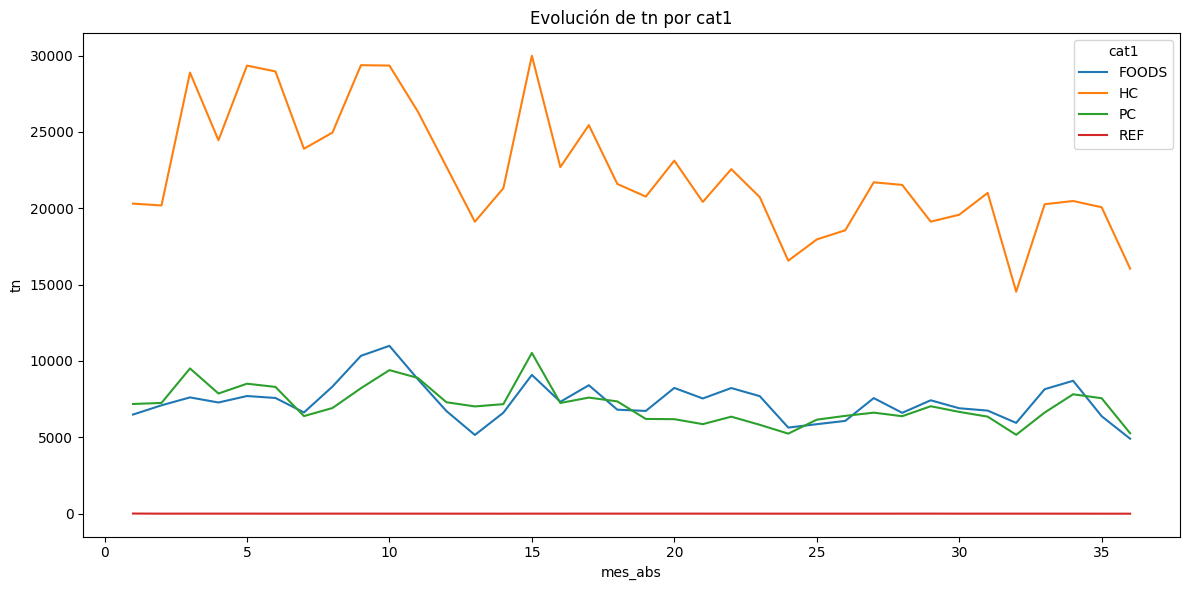

In [ ]:
import matplotlib.pyplot as plt

# Agrupar por cat1 y mes_abs, sumar tn
df_cat1 = df_agg_prod.groupby(['cat1', 'mes_abs'], as_index=False)['tn'].sum()

# Pivotear para tener cat1 como columnas
df_pivot = df_cat1.pivot(index='mes_abs', columns='cat1', values='tn')

# Graficar
df_pivot.plot(figsize=(12, 6))
plt.title('Evolución de tn por cat1')
plt.xlabel('mes_abs')
plt.ylabel('tn')
plt.legend(title='cat1')
plt.tight_layout()
plt.show()

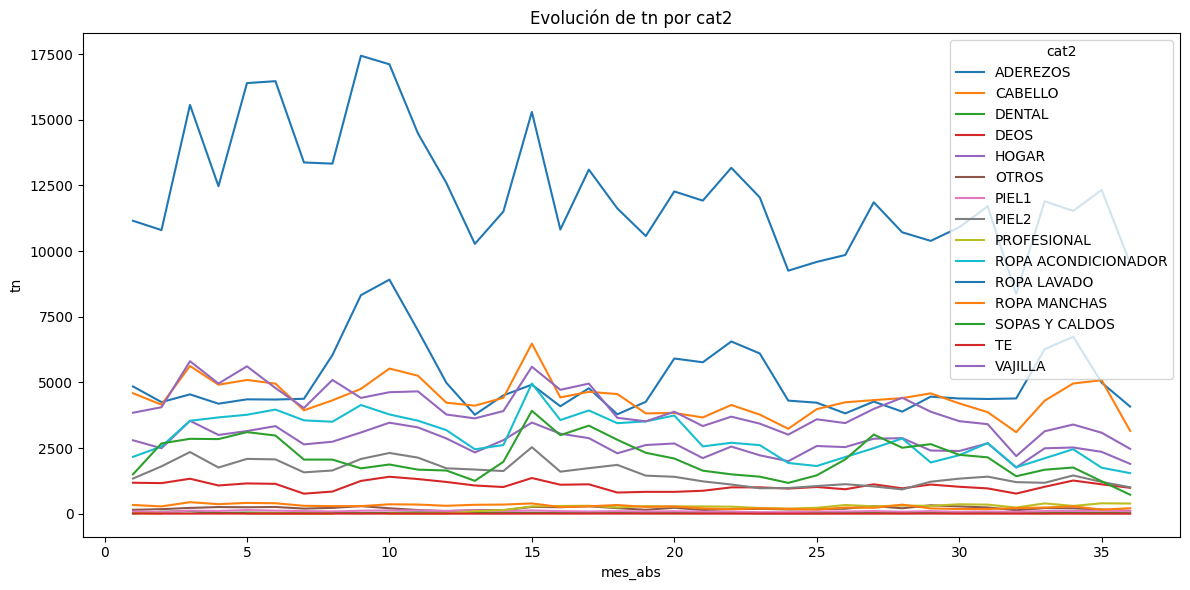

In [ ]:
import matplotlib.pyplot as plt

# Agrupar por cat1 y mes_abs, sumar tn
df_cat1 = df_agg_prod.groupby(['cat2', 'mes_abs'], as_index=False)['tn'].sum()

# Pivotear para tener cat1 como columnas
df_pivot = df_cat1.pivot(index='mes_abs', columns='cat2', values='tn')

# Graficar
df_pivot.plot(figsize=(12, 6))
plt.title('Evolución de tn por cat2')
plt.xlabel('mes_abs')
plt.ylabel('tn')
plt.legend(title='cat2')
plt.tight_layout()
plt.show()

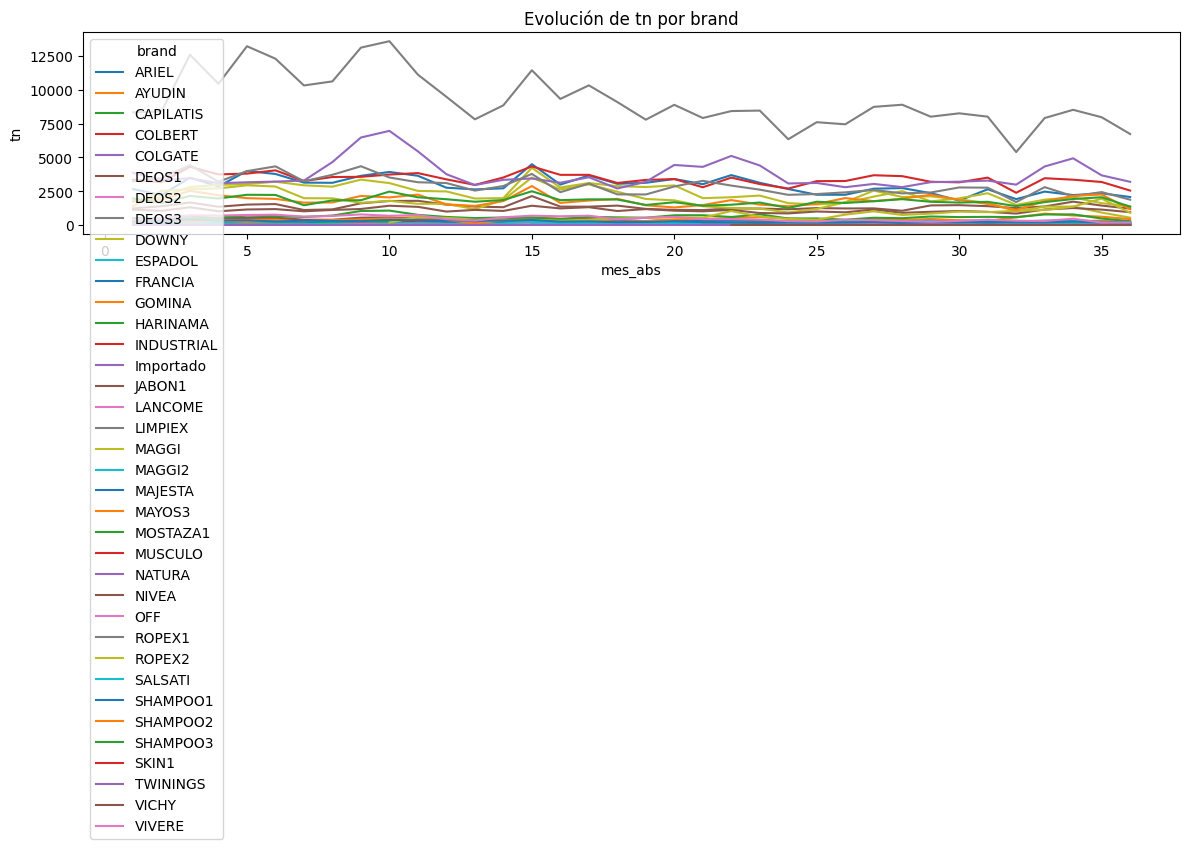

In [ ]:
import matplotlib.pyplot as plt

# Agrupar por cat1 y mes_abs, sumar tn
df_cat1 = df_agg_prod.groupby(['brand', 'mes_abs'], as_index=False)['tn'].sum()

# Pivotear para tener cat1 como columnas
df_pivot = df_cat1.pivot(index='mes_abs', columns='brand', values='tn')

# Graficar
df_pivot.plot(figsize=(12, 6))
plt.title('Evolución de tn por brand')
plt.xlabel('mes_abs')
plt.ylabel('tn')
plt.legend(title='brand')
plt.tight_layout()
plt.show()

In [ ]:
# Crear datasets por categoría usando los 33 productos mágicos del profesor
print("🎯 CREANDO DATASETS POR CATEGORÍA CON LOS 33 PRODUCTOS MÁGICOS DEL PROFESOR")
print("=" * 80)

# Los 33 productos mágicos del profesor
magicos_profesor = [
    20002, 20003, 20006, 20010, 20011, 20018, 20019, 20021,
    20026, 20028, 20035, 20039, 20042, 20044, 20045, 20046, 20049,
    20051, 20052, 20053, 20055, 20008, 20001, 20017, 20086, 20180,
    20193, 20320, 20532, 20612, 20637, 20807, 20838
]

# Obtener información completa de los productos del profesor
df_productos_profesor_completo = df_agg_prod[df_agg_prod['product_id'].isin(magicos_profesor)][['product_id', 'cat1', 'cat2', 'brand']].drop_duplicates()

# Crear diccionario con los productos mágicos del profesor por categoría
magicos_profesor_por_categoria = {}
datasets_profesor_por_categoria = {}

for cat1_value in df_productos_profesor_completo['cat1'].dropna().unique():
    # Obtener productos de esta categoría
    productos_cat = df_productos_profesor_completo[df_productos_profesor_completo['cat1'] == cat1_value]['product_id'].tolist()
    magicos_profesor_por_categoria[cat1_value] = productos_cat
    
    # Crear dataset filtrado para esta categoría
    # Usar solo los productos mágicos del profesor que pertenecen a esta categoría
    df_cat = df_agg_prod[
        (df_agg_prod['cat1'] == cat1_value) & 
        (df_agg_prod['product_id'].isin(productos_cat))
    ].copy()
    
    # Mantener solo las columnas de df_agg para consistencia
    datasets_profesor_por_categoria[cat1_value] = df_cat[df_agg.columns]
    
    print(f"📦 {cat1_value}: {len(productos_cat)} productos mágicos")
    print(f"   IDs: {productos_cat}")
    print(f"   Dataset shape: {datasets_profesor_por_categoria[cat1_value].shape}")
    print()

# Verificar que tenemos todos los productos
total_productos = sum(len(productos) for productos in magicos_profesor_por_categoria.values())
print(f"✅ Total productos distribuidos: {total_productos} (esperado: 33)")

# Mostrar resumen por categoría
print("\n📊 RESUMEN POR CATEGORÍA:")
print("=" * 60)
for cat1_value, productos in magicos_profesor_por_categoria.items():
    print(f"- {cat1_value}: {len(productos)} productos")
    
# Guardar información para usar en modelos
print("\n💾 GUARDANDO INFORMACIÓN...")
import json

# Guardar los productos por categoría en un archivo JSON
with open('magicos_profesor_por_categoria.json', 'w') as f:
    # Convertir a formato serializable
    datos_serializables = {str(k): v for k, v in magicos_profesor_por_categoria.items()}
    json.dump(datos_serializables, f, indent=2)

print("✅ Productos por categoría guardados en 'magicos_profesor_por_categoria.json'")

# Crear archivo CSV con la información detallada
df_resumen_profesor = df_productos_profesor_completo.copy()
df_resumen_profesor.to_csv('productos_magicos_profesor_por_categoria.csv', index=False)
print("✅ Información detallada guardada en 'productos_magicos_profesor_por_categoria.csv'")

🎯 CREANDO DATASETS POR CATEGORÍA CON LOS 33 PRODUCTOS MÁGICOS DEL PROFESOR
📦 HC: 20 productos mágicos
   IDs: [20001, 20002, 20006, 20008, 20010, 20011, 20017, 20018, 20021, 20026, 20028, 20035, 20039, 20042, 20045, 20049, 20051, 20053, 20055, 20180]
   Dataset shape: (713, 16)

📦 FOODS: 5 productos mágicos
   IDs: [20003, 20019, 20046, 20052, 20086]
   Dataset shape: (180, 16)

📦 PC: 8 productos mágicos
   IDs: [20044, 20193, 20320, 20532, 20612, 20637, 20807, 20838]
   Dataset shape: (288, 16)

✅ Total productos distribuidos: 33 (esperado: 33)

📊 RESUMEN POR CATEGORÍA:
- HC: 20 productos
- FOODS: 5 productos
- PC: 8 productos

💾 GUARDANDO INFORMACIÓN...
✅ Productos por categoría guardados en 'magicos_profesor_por_categoria.json'
✅ Información detallada guardada en 'productos_magicos_profesor_por_categoria.csv'


In [ ]:
# Ejemplo: Entrenar modelos de regresión lineal por categoría
print("🚀 ENTRENANDO MODELOS POR CATEGORÍA")
print("=" * 60)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Diccionario para guardar los modelos entrenados
modelos_por_categoria = {}
estadisticas_por_categoria = {}

# Features y target
features = ['tn'] + [f'tn_{i}' for i in range(1, 12)]
target = 'tn+2'

print("📊 ENTRENANDO MODELOS:")
print("=" * 40)

for cat1_value, dataset in datasets_profesor_por_categoria.items():
    print(f"\n🔄 Procesando categoría: {cat1_value}")
    
    # Filtrar datos para entrenamiento (mes_abs == 24)
    df_train_cat = dataset[dataset['mes_abs'] == 24].copy()
    
    # Eliminar registros con valores faltantes
    df_train_cat = df_train_cat.dropna(subset=features + [target])
    
    if len(df_train_cat) == 0:
        print(f"   ⚠️  No hay datos válidos para entrenamiento en {cat1_value}")
        continue
    
    # Preparar datos
    X = df_train_cat[features]
    y = df_train_cat[target]
    
    # Entrenar modelo
    modelo = LinearRegression()
    modelo.fit(X, y)
    
    # Calcular estadísticas
    y_pred = modelo.predict(X)
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    
    # Guardar modelo y estadísticas
    modelos_por_categoria[cat1_value] = modelo
    estadisticas_por_categoria[cat1_value] = {
        'n_samples': len(df_train_cat),
        'mse': mse,
        'r2': r2,
        'rmse': np.sqrt(mse)
    }
    
    print(f"   ✅ Modelo entrenado:")
    print(f"      - Muestras: {len(df_train_cat)}")
    print(f"      - R²: {r2:.4f}")
    print(f"      - RMSE: {np.sqrt(mse):.4f}")

# Mostrar resumen final
print(f"\n📊 RESUMEN FINAL:")
print("=" * 60)
print(f"Modelos entrenados exitosamente: {len(modelos_por_categoria)}")

for cat1_value, stats in estadisticas_por_categoria.items():
    print(f"\n📦 {cat1_value}:")
    print(f"   - Muestras: {stats['n_samples']}")
    print(f"   - R²: {stats['r2']:.4f}")
    print(f"   - RMSE: {stats['rmse']:.4f}")

# Guardar modelos (opcional)
print(f"\n💾 Los modelos están guardados en la variable 'modelos_por_categoria'")
print(f"💾 Las estadísticas están en 'estadisticas_por_categoria'")

# Mostrar cómo usar los modelos
print(f"\n🎯 CÓMO USAR LOS MODELOS:")
print("=" * 60)
print("# Para predecir con el modelo de HC:")
print("# modelo_hc = modelos_por_categoria['HC']")
print("# prediccion = modelo_hc.predict(X_new)")
print()
print("# Para ver coeficientes del modelo de HC:")
print("# coef_hc = pd.DataFrame({")
print("#     'feature': ['intercept'] + features,")
print("#     'coeficiente': [modelo_hc.intercept_] + list(modelo_hc.coef_)")
print("# })")
print("# print(coef_hc)")

🚀 ENTRENANDO MODELOS POR CATEGORÍA
📊 ENTRENANDO MODELOS:

🔄 Procesando categoría: HC
   ✅ Modelo entrenado:
      - Muestras: 20
      - R²: 0.9934
      - RMSE: 24.6222

🔄 Procesando categoría: FOODS
   ✅ Modelo entrenado:
      - Muestras: 5
      - R²: 1.0000
      - RMSE: 0.0000

🔄 Procesando categoría: PC
   ✅ Modelo entrenado:
      - Muestras: 8
      - R²: 1.0000
      - RMSE: 0.0000

📊 RESUMEN FINAL:
Modelos entrenados exitosamente: 3

📦 HC:
   - Muestras: 20
   - R²: 0.9934
   - RMSE: 24.6222

📦 FOODS:
   - Muestras: 5
   - R²: 1.0000
   - RMSE: 0.0000

📦 PC:
   - Muestras: 8
   - R²: 1.0000
   - RMSE: 0.0000

💾 Los modelos están guardados en la variable 'modelos_por_categoria'
💾 Las estadísticas están en 'estadisticas_por_categoria'

🎯 CÓMO USAR LOS MODELOS:
# Para predecir con el modelo de HC:
# modelo_hc = modelos_por_categoria['HC']
# prediccion = modelo_hc.predict(X_new)

# Para ver coeficientes del modelo de HC:
# coef_hc = pd.DataFrame({
#     'feature': ['intercept'] 

In [ ]:
# Ejemplo específico: Modelo de HC
print("🏠 MODELO ESPECÍFICO PARA HC")
print("=" * 60)

# Trabajar específicamente con HC
modelo_hc = modelos_por_categoria['HC']
dataset_hc = datasets_profesor_por_categoria['HC']
productos_hc = magicos_profesor_por_categoria['HC']

print(f"📊 Información del modelo HC:")
print(f"   - Productos mágicos: {len(productos_hc)}")
print(f"   - IDs: {productos_hc}")
print(f"   - R²: {estadisticas_por_categoria['HC']['r2']:.4f}")
print(f"   - RMSE: {estadisticas_por_categoria['HC']['rmse']:.4f}")

# Ver coeficientes del modelo HC
print(f"\n📈 COEFICIENTES DEL MODELO HC:")
print("=" * 50)
coef_hc = pd.DataFrame({
    'feature': ['intercept'] + features,
    'coeficiente': [modelo_hc.intercept_] + list(modelo_hc.coef_)
})
coef_hc['abs_coef'] = coef_hc['coeficiente'].abs()
coef_hc_ordenado = coef_hc.sort_values('abs_coef', ascending=False)
print(coef_hc_ordenado[['feature', 'coeficiente']].to_string(index=False))

# Datos de entrenamiento HC
df_train_hc = dataset_hc[dataset_hc['mes_abs'] == 24].dropna(subset=features + [target])
print(f"\n📋 DATOS DE ENTRENAMIENTO HC:")
print(f"   - Registros: {len(df_train_hc)}")
print(f"   - Período: mes_abs 24 (201812)")
print(f"   - Target: tn+2 (predicción para 202002)")

# Mostrar algunos datos de ejemplo
print(f"\n🔍 MUESTRA DE DATOS HC:")
print("=" * 50)
muestra_hc = df_train_hc[['product_id', 'tn', 'tn_1', 'tn_2', 'tn_10', 'tn+2']].head(5)
display(muestra_hc)

# Crear función para predecir con HC
def predecir_hc(df_input):
    """
    Función para hacer predicciones con el modelo HC
    
    Parameters:
    df_input: DataFrame con las columnas ['tn', 'tn_1', 'tn_2', ..., 'tn_11']
    
    Returns:
    array con las predicciones
    """
    if not all(col in df_input.columns for col in features):
        print("⚠️  Error: Faltan columnas necesarias")
        return None
    
    return modelo_hc.predict(df_input[features])

print(f"\n🎯 FUNCIÓN DE PREDICCIÓN CREADA:")
print("=" * 50)
print("Usa: predecir_hc(df_input)")
print("donde df_input debe tener las columnas:", features)

# Ejemplo de uso
print(f"\n🧪 EJEMPLO DE PREDICCIÓN:")
print("=" * 50)
ejemplo_pred = predecir_hc(df_train_hc.head(3))
print(f"Predicciones para los primeros 3 registros de HC:")
for i, pred in enumerate(ejemplo_pred):
    actual = df_train_hc.iloc[i][target]
    print(f"   Producto {df_train_hc.iloc[i]['product_id']}: Predicción={pred:.2f}, Real={actual:.2f}")

print(f"\n✅ Modelo HC listo para usar!")
print("Variables disponibles:")
print("   - modelo_hc: el modelo entrenado")
print("   - dataset_hc: datos completos de HC")
print("   - productos_hc: lista de product_ids mágicos de HC")
print("   - predecir_hc(): función para hacer predicciones")

🏠 MODELO ESPECÍFICO PARA HC
📊 Información del modelo HC:
   - Productos mágicos: 20
   - IDs: [20001, 20002, 20006, 20008, 20010, 20011, 20017, 20018, 20021, 20026, 20028, 20035, 20039, 20042, 20045, 20049, 20051, 20053, 20055, 20180]
   - R²: 0.9934
   - RMSE: 24.6222

📈 COEFICIENTES DEL MODELO HC:
  feature  coeficiente
intercept     7.052647
     tn_5    -0.653148
       tn     0.353700
    tn_10     0.310837
     tn_2     0.258774
     tn_6     0.211296
     tn_7     0.169667
     tn_3     0.145821
     tn_9    -0.134153
    tn_11     0.132057
     tn_8     0.118243
     tn_1     0.058473
     tn_4    -0.031292

📋 DATOS DE ENTRENAMIENTO HC:
   - Registros: 20
   - Período: mes_abs 24 (201812)
   - Target: tn+2 (predicción para 202002)

🔍 MUESTRA DE DATOS HC:


,product_id,tn,tn_1,tn_2,tn_10,tn+2
23,20001,1486.68669,1813.01511,2295.19832,1043.76470,1259.09363
59,20002,1009.45458,1766.81068,1378.49032,712.00087,1043.01349
203,20006,407.75925,566.66809,513.15472,588.56272,479.99914
275,20008,426.32899,433.50170,532.45644,506.25385,476.98787
347,20010,285.02947,414.97753,612.50721,477.48363,337.76009



🎯 FUNCIÓN DE PREDICCIÓN CREADA:
Usa: predecir_hc(df_input)
donde df_input debe tener las columnas: ['tn', 'tn_1', 'tn_2', 'tn_3', 'tn_4', 'tn_5', 'tn_6', 'tn_7', 'tn_8', 'tn_9', 'tn_10', 'tn_11']

🧪 EJEMPLO DE PREDICCIÓN:
Predicciones para los primeros 3 registros de HC:
   Producto 20001.0: Predicción=1266.25, Real=1259.09
   Producto 20002.0: Predicción=1033.99, Real=1043.01
   Producto 20006.0: Predicción=494.76, Real=480.00

✅ Modelo HC listo para usar!
Variables disponibles:
   - modelo_hc: el modelo entrenado
   - dataset_hc: datos completos de HC
   - productos_hc: lista de product_ids mágicos de HC
   - predecir_hc(): función para hacer predicciones


In [ ]:
# Aplicar el modelo HC específico para hacer predicciones en 201912
print("🎯 APLICANDO MODELO HC PARA PREDICCIONES EN 201912")
print("=" * 60)

# Filtrar solo productos HC en mes_abs == 36 (201912)
df_pred_hc = df_agg[
    (df_agg['mes_abs'] == 36) & 
    (df_agg['product_id'].isin(productos_hc))
].copy()

print(f"📊 Productos HC encontrados en 201912: {len(df_pred_hc)}")

# Determinar qué productos tienen todos los features disponibles
df_pred_hc['completos'] = df_pred_hc[features].notnull().all(axis=1)

# Separar completos e incompletos
df_completos_hc = df_pred_hc[df_pred_hc['completos']].copy()
df_incompletos_hc = df_pred_hc[~df_pred_hc['completos']].copy()

print(f"   - Completos: {len(df_completos_hc)}")
print(f"   - Incompletos: {len(df_incompletos_hc)}")

# --- PREDICCIÓN PARA COMPLETOS HC ---
if len(df_completos_hc) > 0:
    df_completos_hc['pred'] = predecir_hc(df_completos_hc)
    df_completos_hc['pred_tipo'] = 'modelo_hc'
    print(f"✅ Predicciones realizadas para {len(df_completos_hc)} productos HC completos")
else:
    print("⚠️  No hay productos HC completos para predecir")

# --- MANEJO DE INCOMPLETOS HC ---
if len(df_incompletos_hc) > 0:
    print(f"\n🔧 Procesando {len(df_incompletos_hc)} productos HC incompletos...")
    
    # Aplicar promedio ponderado para incompletos HC
    pesos = np.array([
        4.0,   # tn        → muy reciente
        3.0,   # tn_1      → reciente
        2.0,   # tn_2      → reciente
        1.5,   # tn_3
        1.5,   # tn_4
        1.5,   # tn_5
        1.2,   # tn_6
        1.0,   # tn_7
        1.0,   # tn_8
        1.0,   # tn_9
        45.0,  # tn_10 → febrero anterior, fuerte estacionalidad
        1.0    # tn_11
    ])
    
    # Extraer matriz de features
    X_incompletos_hc = df_incompletos_hc[features].values
    
    # Crear máscara de valores válidos
    máscara_validos = ~np.isnan(X_incompletos_hc)
    
    # Expandir pesos por fila, aplicando la máscara
    pesos_expandido = np.tile(pesos, (X_incompletos_hc.shape[0], 1))
    pesos_validos = pesos_expandido * máscara_validos
    
    # Calcular promedio ponderado por fila
    suma_ponderada = np.nansum(X_incompletos_hc * pesos_validos, axis=1)
    suma_pesos = np.nansum(pesos_validos, axis=1)
    df_incompletos_hc['pred'] = suma_ponderada / suma_pesos
    df_incompletos_hc['pred_tipo'] = 'promedio_hc'
    
    print(f"✅ Predicciones por promedio ponderado para {len(df_incompletos_hc)} productos HC incompletos")

# --- UNIÓN FINAL HC ---
if len(df_completos_hc) > 0 and len(df_incompletos_hc) > 0:
    df_final_hc = pd.concat([df_completos_hc, df_incompletos_hc], axis=0).sort_values('product_id')
elif len(df_completos_hc) > 0:
    df_final_hc = df_completos_hc.sort_values('product_id')
elif len(df_incompletos_hc) > 0:
    df_final_hc = df_incompletos_hc.sort_values('product_id')
else:
    df_final_hc = pd.DataFrame()

# --- VALIDACIÓN DE RESULTADOS HC ---
if len(df_final_hc) > 0:
    print(f"\n🔍 RESULTADOS CATEGORÍA HC:")
    print("=" * 60)
    print(f"Suma de TN a 201912 (HC): {df_final_hc['tn'].sum():,.2f}")
    print(f"Suma de predicciones a 202002 (HC): {df_final_hc['pred'].sum():,.2f}")
    
    print(f"\n📦 Desglose HC:")
    print(f"Total productos HC: {len(df_final_hc)}")
    print(f"Tipos de predicción:")
    print(df_final_hc['pred_tipo'].value_counts())
    
    # --- VISTA RÁPIDA ---
    print(f"\n🔍 Muestra de predicciones HC:")
    display(df_final_hc[['product_id', 'periodo', 'pred', 'pred_tipo']].head())
    
    # Guardar archivo específico de HC
    import os
    from datetime import datetime
    
    os.makedirs("kaggle", exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")
    filename_hc = f"kaggle/predicciones_HC_categories_{timestamp}.csv"
    
    df_final_hc[['product_id', 'pred']].to_csv(filename_hc, index=False)
    print(f"\n💾 Archivo guardado como: {filename_hc}")
    print(f"📊 Productos HC exportados: {len(df_final_hc)}")
    
else:
    print("⚠️  No se encontraron productos HC para predecir")

🎯 APLICANDO MODELO HC PARA PREDICCIONES EN 201912
📊 Productos HC encontrados en 201912: 20
   - Completos: 20
   - Incompletos: 0
✅ Predicciones realizadas para 20 productos HC completos

🔍 RESULTADOS CATEGORÍA HC:
Suma de TN a 201912 (HC): 5,952.89
Suma de predicciones a 202002 (HC): 6,709.09

📦 Desglose HC:
Total productos HC: 20
Tipos de predicción:
pred_tipo
modelo_hc    20
Name: count, dtype: int64

🔍 Muestra de predicciones HC:


,product_id,periodo,pred,pred_tipo
35,20001,201912,1199.431439,modelo_hc
71,20002,201912,1294.224289,modelo_hc
215,20006,201912,585.496579,modelo_hc
287,20008,201912,324.309231,modelo_hc
359,20010,201912,377.964348,modelo_hc



💾 Archivo guardado como: kaggle/predicciones_HC_categories_20250718_1310.csv
📊 Productos HC exportados: 20


In [ ]:
df_final_hc[['product_id', 'pred']]

,product_id,pred
35,20001,1199.431439
71,20002,1294.224289
215,20006,585.496579
287,20008,324.309231
359,20010,377.964348
395,20011,344.551890
611,20017,322.556302
647,20018,292.316922
755,20021,264.909606
935,20026,264.252866


Acá, básicamente agarro el output del baseline del profesor. Y reemplazamos los valores de los resultados de HC en el mismo. Sería el equivalente a correr un modelo especializado en HC para los productos HC, y otro general para todo el resto (y poniendo la media en los que no tienen 12 meses de historia)

In [ ]:
# Leer el archivo original de predicciones
df_pred_orig = pd.read_csv("kaggle/predicciones_201912_20250704_1504.csv")

# Reemplazar los valores de HC por los nuevos obtenidos en df_final_hc
# Nos aseguramos de tener solo las columnas necesarias
df_hc_nuevos = df_final_hc[['product_id', 'pred']].copy()

# Hacemos el merge para reemplazar solo los productos HC
df_pred_actualizado = df_pred_orig.set_index('product_id')
df_hc_nuevos = df_hc_nuevos.set_index('product_id')

# Actualizar los valores de pred para los productos HC
df_pred_actualizado.update(df_hc_nuevos)

# Resetear el índice para guardar el archivo
df_pred_actualizado = df_pred_actualizado.reset_index()

# Guardar el nuevo archivo
filename_actualizado = f'kaggle/predicciones_201912_actualizado_{timestamp}.csv'
df_pred_actualizado.to_csv(filename_actualizado, index=False)
print(f"Archivo actualizado guardado como: {filename_actualizado}")

Archivo actualizado guardado como: kaggle/predicciones_201912_actualizado_20250718_1310.csv
